In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import random
import sklearn
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import OneHotEncoder

In [2]:
pip install openpyxl

/bin/bash: /home/jia/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Note: you may need to restart the kernel to use updated packages.


# 1. import data

In [3]:
#dataframe1 = pd.read_excel('Morphometric raw data_3H7CLL.xlsx',sheet_name='Sheet1')
#remember to use the actual excel file name

dataframe1 = pd.read_excel('/home/daizong/Project/Morphometric raw data_3H7CLL(renamed).xlsx',sheet_name='Sheet1')

In [4]:
print(dataframe1)

      Category donor  experiment date stiffness g-a-m conc  sample  slice  \
0      Healthy    H1         20231202     1to10     3ug/ml       1      1   
1      Healthy    H1         20231202     1to10     3ug/ml       1      1   
2      Healthy    H1         20231202     1to10     3ug/ml       1      1   
3      Healthy    H1         20231202     1to10     3ug/ml       1      1   
4      Healthy    H1         20231202     1to10     3ug/ml       1      1   
...        ...   ...              ...       ...        ...     ...    ...   
21542      CLL  CLL7         20240509     1to50     1ug/ml       2      7   
21543      CLL  CLL7         20240509     1to50     1ug/ml       2      7   
21544      CLL  CLL7         20240509     1to50     1ug/ml       2      7   
21545      CLL  CLL7         20240509     1to50     1ug/ml       2      7   
21546      CLL  CLL7         20240509     1to50     1ug/ml       2      7   

       cell number           Label  area (40x)  ...  %Area  RawIntDen  Fere

In [5]:
dataframe1=dataframe1[dataframe1['stiffness']=='1to10']

In [6]:
print(dataframe1)

      Category donor  experiment date stiffness g-a-m conc  sample  slice  \
0      Healthy    H1         20231202     1to10     3ug/ml       1      1   
1      Healthy    H1         20231202     1to10     3ug/ml       1      1   
2      Healthy    H1         20231202     1to10     3ug/ml       1      1   
3      Healthy    H1         20231202     1to10     3ug/ml       1      1   
4      Healthy    H1         20231202     1to10     3ug/ml       1      1   
...        ...   ...              ...       ...        ...     ...    ...   
21110      CLL  CLL7         20240509     1to10     3ug/ml       2     10   
21111      CLL  CLL7         20240509     1to10     3ug/ml       2     10   
21112      CLL  CLL7         20240509     1to10     3ug/ml       2     10   
21113      CLL  CLL7         20240509     1to10     3ug/ml       2     10   
21114      CLL  CLL7         20240509     1to10     3ug/ml       2     10   

       cell number            Label  area (40x)  ...  %Area  RawIntDen  \
0

# 2. Average the data

In [7]:
grouped_multiple = dataframe1.groupby(['Category','donor', 'experiment date','stiffness','sample','slice']).agg({'area (40x)':['mean'],'Perim.':['mean'],'Width':['mean'],'Height':['mean'],'Major':['mean'],'Minor':['mean'],'Circ.':['mean'],'Feret':['mean'],'AR':['mean'],'Round':['mean'],'Solidity': ['mean']})
grouped_multiple.columns = ['area_mean', 'Perim._mean', 'Width_mean','Height_mean','Major_mean','Minor_mean','Circ._mean','Feret_mean','AR_mean','Round_mean','Solidity_mean']
print(grouped_multiple)

                                                       area_mean  Perim._mean  \
Category donor experiment date stiffness sample slice                           
CLL      CLL1  20240217        1to10     1      1      79.576667    36.217833   
                                                2      82.022222    36.237556   
                                                3      65.936000    33.415000   
                                                4      71.101818    33.462455   
                                                5      73.088889    34.708556   
...                                                          ...          ...   
Healthy  H3    20231228        1to10     2      6      60.556000    33.828850   
                                                7      61.355000    32.278833   
                                                8      70.763636    35.081091   
                                                9      70.668148    36.988074   
                            

In [8]:
grouped_df=grouped_multiple.reset_index()

In [9]:
print(grouped_df)

    Category donor  experiment date stiffness  sample  slice  area_mean  \
0        CLL  CLL1         20240217     1to10       1      1  79.576667   
1        CLL  CLL1         20240217     1to10       1      2  82.022222   
2        CLL  CLL1         20240217     1to10       1      3  65.936000   
3        CLL  CLL1         20240217     1to10       1      4  71.101818   
4        CLL  CLL1         20240217     1to10       1      5  73.088889   
..       ...   ...              ...       ...     ...    ...        ...   
472  Healthy    H3         20231228     1to10       2      6  60.556000   
473  Healthy    H3         20231228     1to10       2      7  61.355000   
474  Healthy    H3         20231228     1to10       2      8  70.763636   
475  Healthy    H3         20231228     1to10       2      9  70.668148   
476  Healthy    H3         20231228     1to10       2     10  69.288000   

     Perim._mean  Width_mean  Height_mean  Major_mean  Minor_mean  Circ._mean  \
0      36.217833  

In [10]:
H_df=grouped_df[grouped_df['Category']=='Healthy']
print(H_df)

    Category donor  experiment date stiffness  sample  slice  area_mean  \
310  Healthy    H1         20231122     1to10       1      1  72.078182   
311  Healthy    H1         20231122     1to10       1      2  69.569231   
312  Healthy    H1         20231122     1to10       1      3  62.008889   
313  Healthy    H1         20231122     1to10       1      4  62.974286   
314  Healthy    H1         20231122     1to10       1      5  67.342222   
..       ...   ...              ...       ...     ...    ...        ...   
472  Healthy    H3         20231228     1to10       2      6  60.556000   
473  Healthy    H3         20231228     1to10       2      7  61.355000   
474  Healthy    H3         20231228     1to10       2      8  70.763636   
475  Healthy    H3         20231228     1to10       2      9  70.668148   
476  Healthy    H3         20231228     1to10       2     10  69.288000   

     Perim._mean  Width_mean  Height_mean  Major_mean  Minor_mean  Circ._mean  \
310    37.410091  

In [11]:
#to balance between Healthy and CLL
CLL_df=grouped_df[grouped_df['Category']=='CLL']
import pandas as pd

# Calculate the number of rows to sample (half of the DataFrame)
num_rows_to_sample = len(CLL_df) // 2

# Randomly sample half of the rows
sampled_CLL_df = CLL_df.sample(n=num_rows_to_sample, random_state=42)

# Print the sampled DataFrame
print(sampled_CLL_df)

    Category donor  experiment date stiffness  sample  slice   area_mean  \
289      CLL  CLL7         20240506     1to10       1     10   65.010909   
9        CLL  CLL1         20240217     1to10       1     10   73.637333   
57       CLL  CLL2         20240222     1to10       1      8   60.683333   
60       CLL  CLL2         20240222     1to10       2      1   56.796000   
25       CLL  CLL1         20240221     1to10       2      6   53.870000   
..       ...   ...              ...       ...     ...    ...         ...   
120      CLL  CLL3         20240208     1to10       2      1  100.856000   
222      CLL  CLL5         20240411     1to10       2      3   71.370769   
267      CLL  CLL6         20240424     1to10       1      8   84.185455   
127      CLL  CLL3         20240208     1to10       2      8   62.807273   
74       CLL  CLL2         20240228     1to10       1      5   68.348235   

     Perim._mean  Width_mean  Height_mean  Major_mean  Minor_mean  Circ._mean  \
289   

In [12]:
import pandas as pd

# Assuming H_df and sampled_CLL_df are already defined
# Concatenate the two DataFrames along the rows
grouped_df = pd.concat([H_df, sampled_CLL_df], ignore_index=True)

# Print the combined DataFrame
print(grouped_df)

    Category donor  experiment date stiffness  sample  slice   area_mean  \
0    Healthy    H1         20231122     1to10       1      1   72.078182   
1    Healthy    H1         20231122     1to10       1      2   69.569231   
2    Healthy    H1         20231122     1to10       1      3   62.008889   
3    Healthy    H1         20231122     1to10       1      4   62.974286   
4    Healthy    H1         20231122     1to10       1      5   67.342222   
..       ...   ...              ...       ...     ...    ...         ...   
317      CLL  CLL3         20240208     1to10       2      1  100.856000   
318      CLL  CLL5         20240411     1to10       2      3   71.370769   
319      CLL  CLL6         20240424     1to10       1      8   84.185455   
320      CLL  CLL3         20240208     1to10       2      8   62.807273   
321      CLL  CLL2         20240228     1to10       1      5   68.348235   

     Perim._mean  Width_mean  Height_mean  Major_mean  Minor_mean  Circ._mean  \
0     

# 3. Normalization

In [13]:
from sklearn import preprocessing

In [14]:
norm=preprocessing.StandardScaler()
x=grouped_df[['area_mean', 'Perim._mean', 'Width_mean','Height_mean','Major_mean','Minor_mean','Circ._mean','Feret_mean','AR_mean','Round_mean','Solidity_mean']].values
x_scaled=norm.fit_transform(x)
df=pd.DataFrame(x_scaled)
df.columns= ['Area', 'Perim.', 'Width','Height','Major','Minor','Circ.','Feret','AR','Round','Solidity']

In [15]:
df
#normalized data for PCA

,Area,Perim.,Width,Height,Major,Minor,Circ.,Feret,AR,Round,Solidity
0,0.151430,0.149402,0.711100,0.023238,0.657209,-0.196982,-0.231543,0.712997,0.876369,-0.744942,-0.091904
1,-0.119450,-0.228015,-0.854751,-0.161210,-0.442030,0.018945,0.295981,-0.474362,-0.287624,0.435871,0.447917
2,-0.935704,-0.576778,-0.857017,-0.894451,-1.078792,-0.648085,0.406624,-0.739330,-0.283086,0.328490,-0.049116
3,-0.831474,-0.567434,-1.332599,-0.319309,-0.632300,-0.811395,0.685256,-0.669812,0.107785,-0.071734,0.961094
4,-0.359889,-0.561734,-0.886478,-0.480010,-0.709662,0.165615,1.146440,-0.974436,-0.997907,1.014675,1.317197
...,...,...,...,...,...,...,...,...,...,...,...
317,3.258434,1.112015,2.053709,2.794067,2.235591,3.301182,0.111004,1.866934,-1.012481,0.898452,1.109737
318,0.075054,0.448067,0.797320,0.053980,0.617419,-0.438912,-1.190293,0.522675,1.177386,-1.050891,-1.206633
319,1.458595,0.683349,1.253447,0.241223,1.179769,1.409944,-0.427266,1.076820,0.132053,0.336677,0.061385
320,-0.849506,-0.584415,-0.723105,-0.969803,-1.186933,-0.337653,0.829614,-1.241342,-0.956267,1.143725,1.011033


In [16]:
grouped_df[['area_mean','Perim._mean','Width_mean','Height_mean','Major_mean','Minor_mean','Circ._mean','Feret_mean','AR_mean','Round_mean','Solidity_mean']]= df [['Area', 'Perim.', 'Width','Height','Major','Minor','Circ.','Feret','AR','Round','Solidity' ]]

In [17]:
print(grouped_df)

    Category donor  experiment date stiffness  sample  slice  area_mean  \
0    Healthy    H1         20231122     1to10       1      1   0.151430   
1    Healthy    H1         20231122     1to10       1      2  -0.119450   
2    Healthy    H1         20231122     1to10       1      3  -0.935704   
3    Healthy    H1         20231122     1to10       1      4  -0.831474   
4    Healthy    H1         20231122     1to10       1      5  -0.359889   
..       ...   ...              ...       ...     ...    ...        ...   
317      CLL  CLL3         20240208     1to10       2      1   3.258434   
318      CLL  CLL5         20240411     1to10       2      3   0.075054   
319      CLL  CLL6         20240424     1to10       1      8   1.458595   
320      CLL  CLL3         20240208     1to10       2      8  -0.849506   
321      CLL  CLL2         20240228     1to10       1      5  -0.251275   

     Perim._mean  Width_mean  Height_mean  Major_mean  Minor_mean  Circ._mean  \
0       0.149402  

# 4. PCA

In [18]:
from sklearn.decomposition import PCA
pca = PCA(n_components=4)
pca.fit(df)

PCA(n_components=4)

In [19]:
print(pca.explained_variance_ratio_)

[0.57132074 0.24672385 0.1408612  0.0198491 ]


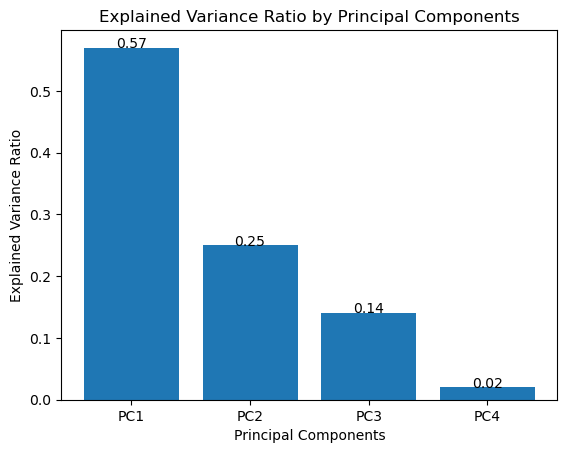

In [20]:
def addlabels(x, y):
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha='center')

# Bar plot for explained variance ratio
fig, ax = plt.subplots()
x_axis = ['PC1', 'PC2', 'PC3', 'PC4']
y_axis = np.round(pca.explained_variance_ratio_, 2)
ax.bar(x_axis, y_axis)
addlabels(x_axis, y_axis)
plt.title('Explained Variance Ratio by Principal Components')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.show()

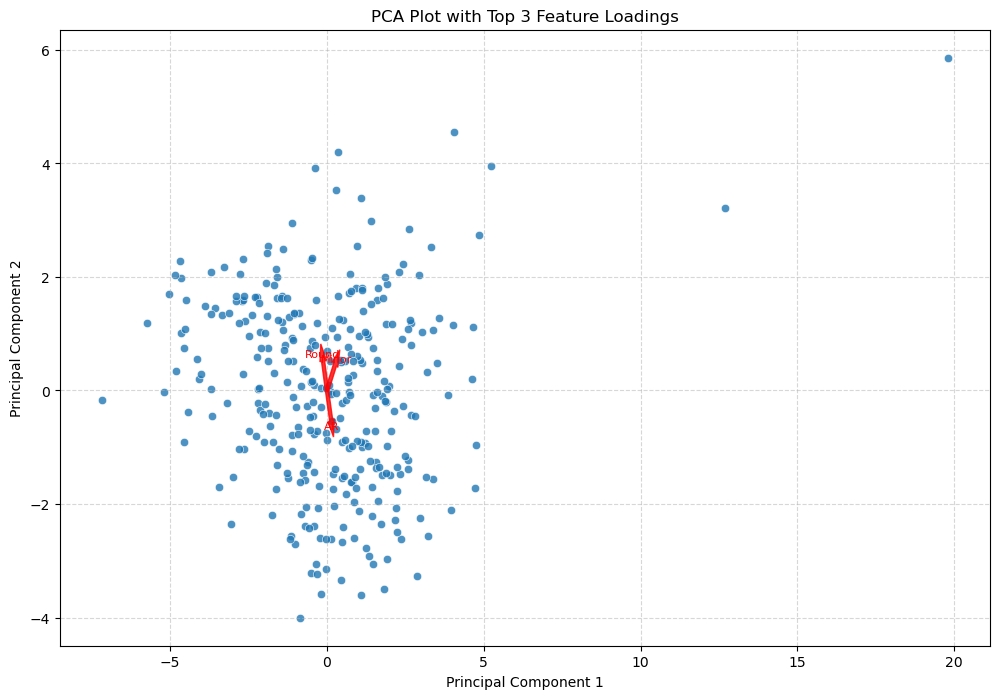

In [21]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# Fit PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df)

# Get the loadings (correlation coefficients) of each feature with PC1 and PC2
loadings = pca.components_[:2, :].T

# Create a DataFrame with loadings
loadings_df = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=df.columns)

# Select the top N features with the highest loadings
top_n_features = 3  # Adjust this value based on your preference
top_features = abs(loadings_df).sum(axis=1).nlargest(top_n_features).index

# Plot PCA scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], alpha=0.8)

# Overlay vectors for top N feature loadings
for feature in top_features:
    plt.arrow(0, 0, loadings_df.loc[feature, 'PC1'], loadings_df.loc[feature, 'PC2'],
              color='r', alpha=0.8, width=0.1, head_width=0.2, zorder=10)
    plt.text(loadings_df.loc[feature, 'PC1']*1.2, loadings_df.loc[feature, 'PC2']*1.2,
             feature, color='r', ha='center', va='center', fontsize=8, zorder=10)

plt.title(f'PCA Plot with Top {top_n_features} Feature Loadings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

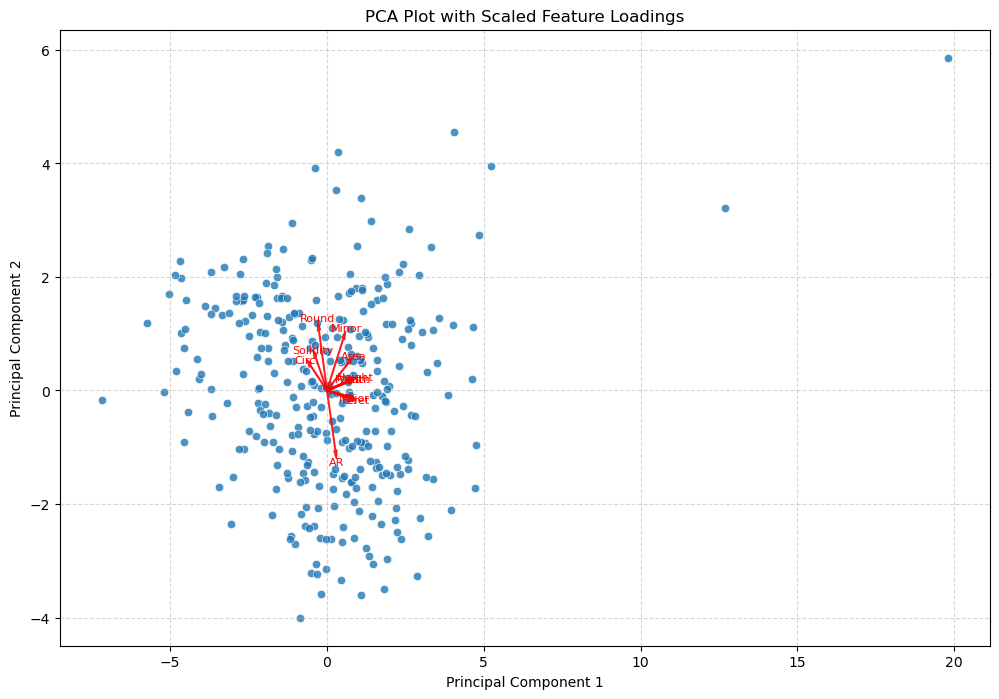

In [22]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# Fit PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df)

# Get the loadings (correlation coefficients) of each feature with PC1 and PC2
loadings = pca.components_[:2, :].T

# Create a DataFrame with loadings
loadings_df = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=df.columns)

# Scale factor to make arrows more visible
scale_factor = 2

# Plot PCA scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], alpha=0.8)

# Overlay vectors for all features with scaling
for feature in df.columns:
    plt.arrow(0, 0, loadings_df.loc[feature, 'PC1']*scale_factor, loadings_df.loc[feature, 'PC2']*scale_factor,
              color='r', alpha=0.8, width=0.02, head_width=0.1, zorder=10)
    plt.text(loadings_df.loc[feature, 'PC1']*scale_factor*1.2, loadings_df.loc[feature, 'PC2']*scale_factor*1.2,
             feature, color='r', ha='center', va='center', fontsize=8, zorder=10)

plt.title('PCA Plot with Scaled Feature Loadings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

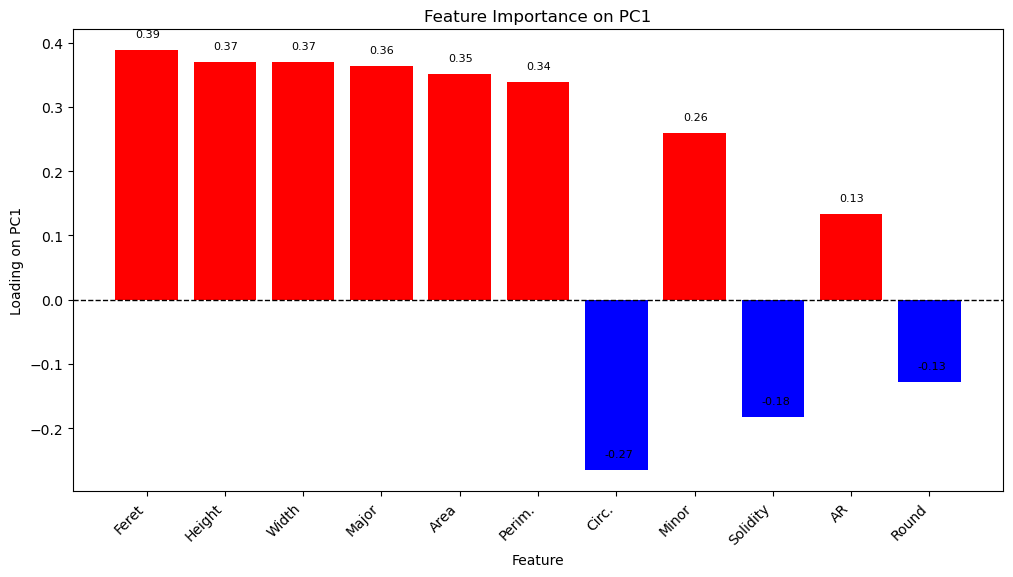

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# Assuming 'df' is your data
# Fit PCA
pca = PCA(n_components=6)
pca.fit(df)

# Get loadings for PC1
loadings_pc1 = pca.components_[0, :]

# Create a DataFrame with feature names and their loadings on PC1
features_pc1_df = pd.DataFrame({'Feature': df.columns, 'Loading_PC1': loadings_pc1})

# Sort the DataFrame by the absolute values of loadings
features_pc1_df = features_pc1_df.reindex(features_pc1_df['Loading_PC1'].abs().sort_values(ascending=False).index)

# Plot a bar graph
plt.figure(figsize=(12, 6))
bars = plt.bar(features_pc1_df['Feature'], features_pc1_df['Loading_PC1'], color=['red' if x > 0 else 'blue' for x in features_pc1_df['Loading_PC1']])
plt.title('Feature Importance on PC1')
plt.xlabel('Feature')
plt.ylabel('Loading on PC1')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility

# Add values on each bar
for bar, value in zip(bars, features_pc1_df['Loading_PC1']):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.15, bar.get_height() + 0.02, f'{value:.2f}', fontsize=8, color='black')

# Add a line at 0
plt.axhline(0, color='black', linewidth=1, linestyle='--')

plt.show()

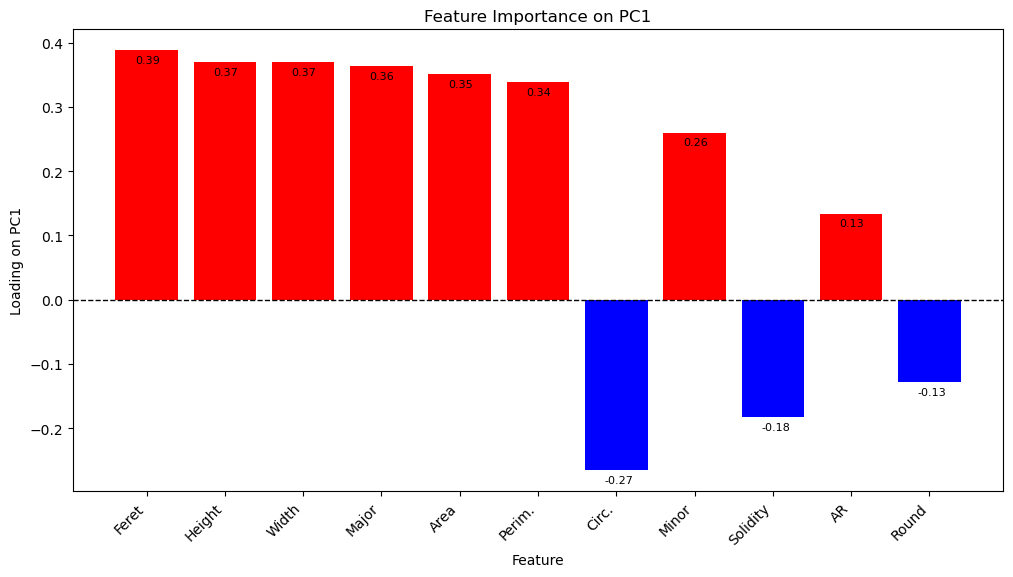

In [24]:
import pandas as pd
from sklearn.decomposition import PCA

# Assuming 'df' is your data
# Fit PCA
pca = PCA(n_components=6)
pca.fit(df)

# Get loadings for PC1
loadings_pc1 = pca.components_[0, :]

# Reverse the sign of loadings if they are negative
loadings_pc1 = -loadings_pc1 if loadings_pc1[0] < 0 else loadings_pc1

# Create a DataFrame with feature names and their loadings on PC1
features_pc1_df = pd.DataFrame({'Feature': df.columns, 'Loading_PC1': loadings_pc1})

# Sort the DataFrame by the absolute values of loadings
features_pc1_df = features_pc1_df.reindex(features_pc1_df['Loading_PC1'].abs().sort_values(ascending=False).index)

# Plot a bar graph
plt.figure(figsize=(12, 6))
bars = plt.bar(features_pc1_df['Feature'], features_pc1_df['Loading_PC1'], color=['red' if x > 0 else 'blue' for x in features_pc1_df['Loading_PC1']])
plt.title('Feature Importance on PC1')
plt.xlabel('Feature')
plt.ylabel('Loading on PC1')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility

# Add values on each bar
for bar, value in zip(bars, features_pc1_df['Loading_PC1']):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.15, bar.get_height() - 0.02, f'{value:.2f}', fontsize=8, color='black')

# Add a line at 0
plt.axhline(0, color='black', linewidth=1, linestyle='--')

plt.savefig('figure3D.png', dpi=300)

plt.show()

# 5. Visualization 

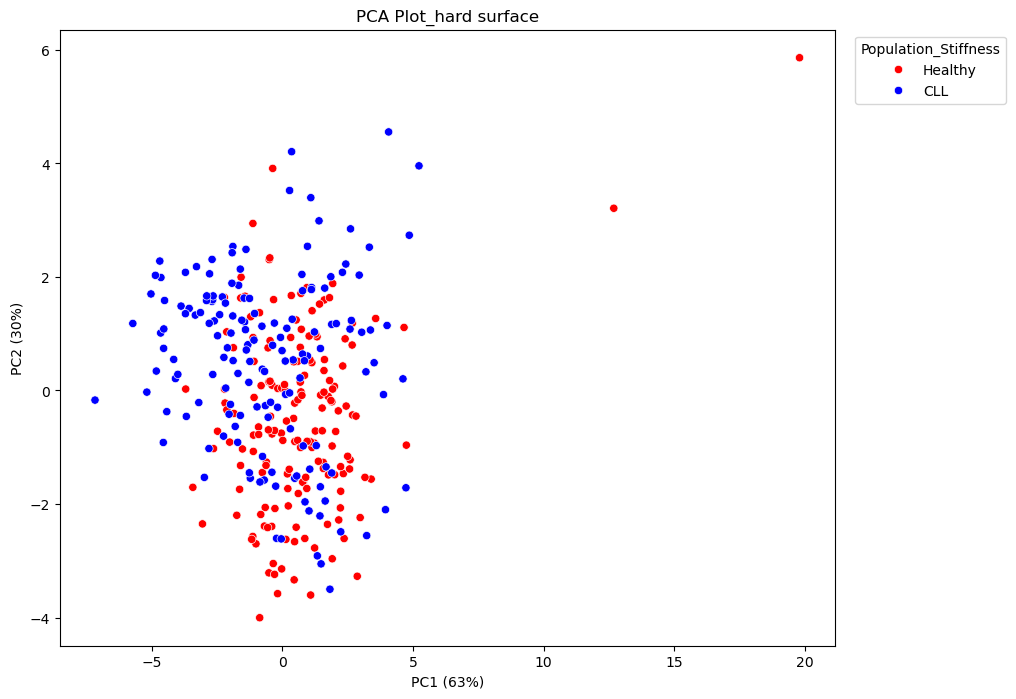

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = {
    'Healthy': 'red',
    'CLL': 'blue'
}

pca_data = pca.transform(df)
pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2', 'PC3', 'PC4','PC5','PC6'])

plt.figure(figsize=(10, 8))
scatter_plot = sns.scatterplot(x='PC1', y='PC2', data=pca_df, hue=grouped_df['Category'], palette=colors)


plt.title('PCA Plot_hard surface')

plt.xlabel('PC1 (63%)')
plt.ylabel('PC2 (30%)')
plt.legend(title='Population_Stiffness', loc='upper right', bbox_to_anchor=(1.23, 1))

plt.show()



## HvsCLL Classification on hard surfaces

In [26]:
#assign label "0" and "1"
def assignNewLabels(label):
    if label == 'Healthy':
        return 0
    else:
        return 1

In [27]:
grouped_df['label']=grouped_df['Category'].apply(assignNewLabels)
print(grouped_df)

    Category donor  experiment date stiffness  sample  slice  area_mean  \
0    Healthy    H1         20231122     1to10       1      1   0.151430   
1    Healthy    H1         20231122     1to10       1      2  -0.119450   
2    Healthy    H1         20231122     1to10       1      3  -0.935704   
3    Healthy    H1         20231122     1to10       1      4  -0.831474   
4    Healthy    H1         20231122     1to10       1      5  -0.359889   
..       ...   ...              ...       ...     ...    ...        ...   
317      CLL  CLL3         20240208     1to10       2      1   3.258434   
318      CLL  CLL5         20240411     1to10       2      3   0.075054   
319      CLL  CLL6         20240424     1to10       1      8   1.458595   
320      CLL  CLL3         20240208     1to10       2      8  -0.849506   
321      CLL  CLL2         20240228     1to10       1      5  -0.251275   

     Perim._mean  Width_mean  Height_mean  Major_mean  Minor_mean  Circ._mean  \
0       0.149402  

In [28]:
#classification

#healthy_donor_list=['H1','H2','H3']
#CLL_donor_list = ['LK2','LK18','LK51','LK63','LK67','LK75']
healthy_df = grouped_df[grouped_df['Category'] == 'Healthy']
CLL_df = grouped_df[grouped_df['Category'] == 'CLL']

# Split healthy data into train and test sets
healthy_train, healthy_test = train_test_split(healthy_df, test_size=0.2, random_state=42)

# Split CLL data into train and test sets
CLL_train, CLL_test = train_test_split(CLL_df, test_size=0.2, random_state=42)

# Concatenate train and test sets
train_df = pd.concat([healthy_train, CLL_train])
test_df = pd.concat([healthy_test, CLL_test])

#accuracy
multifeature_tree_accuracy=[]
RF_accuracy=[]
singlefeature_accuracy=[]

#AUC
multifeature_tree_AUC=[]
RF_AUC=[]
singlefeature_AUC=[]

#Sensitivity
multifeature_tree_sensitivity=[]
RF_sensitivity=[]
singlefeature_sensitivity=[]

#Specificity
singlefeature_specificity=[]
multifeature_tree_specificity=[]
RF_specificity=[]


for i in range(10):
    
    X_train=train_df[['area_mean','Perim._mean','Width_mean','Height_mean','Major_mean','Minor_mean','Circ._mean','Feret_mean','AR_mean','Round_mean','Solidity_mean']]
    y_train = train_df['label']
    X_test = test_df[['area_mean','Perim._mean','Width_mean','Height_mean','Major_mean','Minor_mean','Circ._mean','Feret_mean','AR_mean','Round_mean','Solidity_mean']]
    y_test = test_df['label']
    
    #decision tree model
    clf_1 = tree.DecisionTreeClassifier() # defining decision tree classifier
    clf_1=clf_1.fit(X_train,y_train) # train data on new data and new target
    y_pred_1 = clf_1.predict(X_test) #  assign removed data as input
    score_1 = accuracy_score(y_test, y_pred_1)
    multifeature_tree_accuracy.append(score_1)
    
    # Access the max_depth property
    max_depth_1 = clf_1.tree_.max_depth
    print("Maximum Depth of Decision Tree:", max_depth_1)

    probs_1=clf_1.predict_proba(X_test)
    auc_1 = np.round(metrics.roc_auc_score(y_test, y_pred_1),2)
    multifeature_tree_AUC.append(auc_1)
    cm1=confusion_matrix(y_test, y_pred_1)
    sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
    multifeature_tree_sensitivity.append(sensitivity1)
    multifeature_tree_specificity.append(specificity1)

    
    
    
    #random forest model
    forest = RandomForestClassifier()
    forest.fit(X_train,y_train)
    y_pred_2 = forest.predict(X_test)
    score_2 = accuracy_score(y_test, y_pred_2)
    RF_accuracy.append(score_2)
    # Access the maximum depth of an individual tree in the forest
    max_depth_tree_2 = max(estimator.tree_.max_depth for estimator in forest.estimators_)
    print("Maximum Depth of a Tree in Random Forest:", max_depth_tree_2)
    probs_2 = forest.predict_proba(X_test)
    auc_2 = np.round(metrics.roc_auc_score(y_test, np.array(probs_2[:,1])),2)
    RF_AUC.append(auc_2)
    cm2=confusion_matrix(y_test, y_pred_2)
    sensitivity2 = cm2[0,0]/(cm2[0,0]+cm2[0,1])
    specificity2 = cm2[1,1]/(cm2[1,0]+cm2[1,1])
    RF_sensitivity.append(sensitivity2)
    RF_specificity.append(specificity2)
    
    #Area_ROC
    clf_3 = tree.DecisionTreeClassifier()
    clf_3 = clf_3.fit(np.array(X_train['area_mean']).reshape(-1,1),np.array(y_train).reshape(-1,1))
    y_pred_3 = clf_3.predict(np.array(X_test['area_mean']).reshape(-1,1)) #  assign removed data as input
    score_3 = accuracy_score(y_test, y_pred_3)
    singlefeature_accuracy.append(score_3)
    #probs_3=clf_3.predict_proba(X_test['area_mean'])
    auc_3 = np.round(metrics.roc_auc_score(y_test, y_pred_3),2)
    singlefeature_AUC.append(auc_3)
    cm3=confusion_matrix(y_test, y_pred_3)
    sensitivity3 = cm3[0,0]/(cm3[0,0]+cm3[0,1])
    specificity3 = cm3[1,1]/(cm3[1,0]+cm3[1,1])
    singlefeature_sensitivity.append(sensitivity3)
    singlefeature_specificity.append(specificity3)



Maximum Depth of Decision Tree: 12
Maximum Depth of a Tree in Random Forest: 16
Maximum Depth of Decision Tree: 12
Maximum Depth of a Tree in Random Forest: 22
Maximum Depth of Decision Tree: 12
Maximum Depth of a Tree in Random Forest: 15
Maximum Depth of Decision Tree: 12
Maximum Depth of a Tree in Random Forest: 17
Maximum Depth of Decision Tree: 12
Maximum Depth of a Tree in Random Forest: 18
Maximum Depth of Decision Tree: 12
Maximum Depth of a Tree in Random Forest: 16
Maximum Depth of Decision Tree: 12
Maximum Depth of a Tree in Random Forest: 16
Maximum Depth of Decision Tree: 12
Maximum Depth of a Tree in Random Forest: 17
Maximum Depth of Decision Tree: 12
Maximum Depth of a Tree in Random Forest: 16
Maximum Depth of Decision Tree: 12
Maximum Depth of a Tree in Random Forest: 16


In [29]:
print('multi-feature Decision Tree Accuracy (10-fold)=' + str(np.round(np.mean(multifeature_tree_accuracy),3)))
print('multi-feature Decision Tree AUC (10-fold)=' + str(np.round(np.mean(multifeature_tree_AUC),3)))
print('multi-feature Decision Tree sensitivity (10-fold)=' + str(np.round(np.mean(multifeature_tree_sensitivity),3)))
print('multi-feature Decision Tree specificity (10-fold)=' + str(np.round(np.mean(multifeature_tree_specificity),3)))

print('Random Forest Accuracy (10-fold)=' + str(np.round(np.mean(RF_accuracy),3)))
print('Random Forest AUC (10-fold)=' + str(np.round(np.mean(RF_AUC),3)))
print('Random Forest sensitivity (10-fold)=' + str(np.round(np.mean(RF_sensitivity),3)))
print('Random Forest specificity (10-fold)=' + str(np.round(np.mean(RF_specificity),3)))

print('single-feature Decision Tree Accuracy (10-fold)=' + str(np.round(np.mean(singlefeature_accuracy),3)))
print('single-feature Decision Tree AUC (10-fold)=' + str(np.round(np.mean(singlefeature_AUC),3)))
print('single-feature Decision Tree sensitivity (10-fold)=' + str(np.round(np.mean(singlefeature_sensitivity),3)))
print('single-feature Decision Tree specificity (10-fold)=' + str(np.round(np.mean(singlefeature_specificity),3)))

multi-feature Decision Tree Accuracy (10-fold)=0.726
multi-feature Decision Tree AUC (10-fold)=0.72
multi-feature Decision Tree sensitivity (10-fold)=0.797
multi-feature Decision Tree specificity (10-fold)=0.648
Random Forest Accuracy (10-fold)=0.705
Random Forest AUC (10-fold)=0.804
Random Forest sensitivity (10-fold)=0.762
Random Forest specificity (10-fold)=0.642
single-feature Decision Tree Accuracy (10-fold)=0.615
single-feature Decision Tree AUC (10-fold)=0.61
single-feature Decision Tree sensitivity (10-fold)=0.647
single-feature Decision Tree specificity (10-fold)=0.581
